# Print Samples for All Labels from SAE Classifier Results

Loads `sae_classifier_results_K2_layer14.json` and `test_results` data, then prints samples for each label 0, 1, ..., K-1 where K is the total number of labels.

In [1]:
import json
import pickle
from pathlib import Path

ARTIFACTS = Path("../artifacts")
CLASSIFIER_PATH = ARTIFACTS / "classifier_results" / "sae_classifier_results_K3_layer14.json"
TEST_DATASET_PATH = ARTIFACTS / "test_results" / "test_dataset.pkl"

In [2]:
# Load classifier results and test dataset
with open(CLASSIFIER_PATH) as f:
    results = json.load(f)

with open(TEST_DATASET_PATH, "rb") as f:
    all_samples = pickle.load(f)

cluster_labels = results["cluster_labels"]
n_graph_nodes = results["n_graph_nodes"]
samples = all_samples[:n_graph_nodes]  # graph covers first n_graph_nodes samples

In [3]:
# Get K = total number of labels and indices/samples per label
K = len(set(cluster_labels))
label_indices = {k: [i for i, lbl in enumerate(cluster_labels) if lbl == k] for k in range(K)}
label_samples = {k: [samples[i] for i in label_indices[k]] for k in range(K)}

for k in range(K):
    print(f"Label {k}: {len(label_samples[k])} samples")
print(f"\nTotal: {n_graph_nodes} graph nodes, K = {K} labels\n")

Label 0: 38 samples
Label 1: 23 samples
Label 2: 139 samples

Total: 200 graph nodes, K = 3 labels



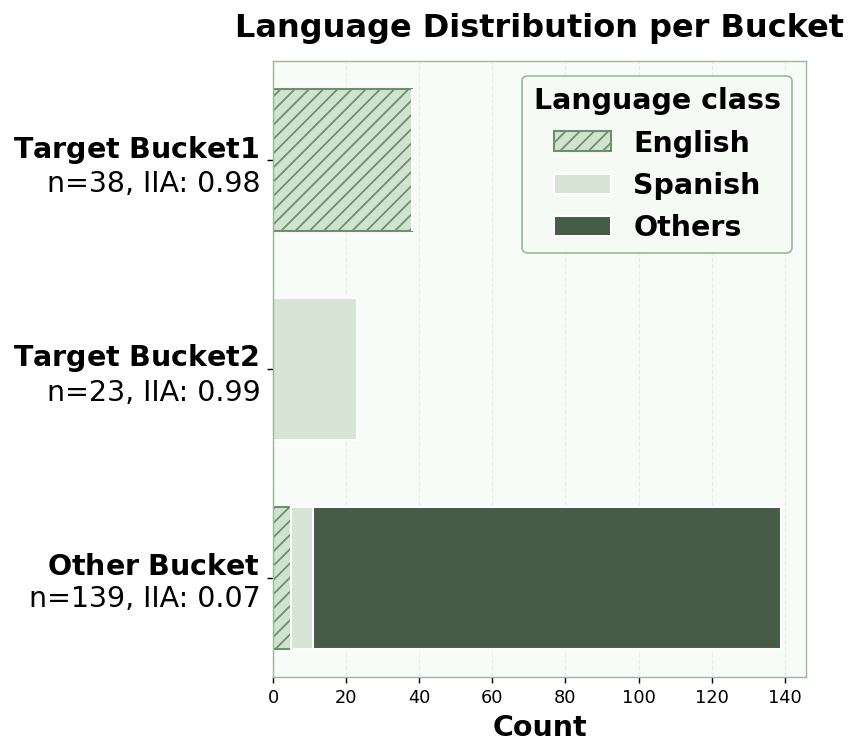

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Coarse language buckets derived from the dataset `gold` string (comma-separated OK).
LANG_ORDER = ["English", "Spanish", "Others"]


def gold_to_lang_class(gold) -> str:
    if gold is None:
        return "Others"
    if isinstance(gold, float) and np.isnan(gold):
        return "Others"
    text = str(gold).strip()
    if not text:
        return "Others"
    parts = [p.strip().lower() for p in text.split(",") if p.strip()]
    if not parts:
        return "Others"
    # If any listed language matches, assign in this priority (multilingual gold).
    if any(p == "english" for p in parts):
        return "English"
    if any(p == "spanish" for p in parts):
        return "Spanish"
    return "Others"


counts = {k: {c: 0 for c in LANG_ORDER} for k in range(K)}
for k in range(K):
    for s in label_samples[k]:
        counts[k][gold_to_lang_class(s.get("gold"))] += 1

# Horizontal stacked bars — green family matching the IIA heatmap style.
# Darken English so it remains visible on light backgrounds.
BAR_COLORS = ["#CFE3CF", "#D6E5D6", "#465C47"] #, "#9EB79F"

fig_h = max(6, 0.62 * K + 2.0)
_max_bucket_n = max(sum(counts[k][c] for c in LANG_ORDER) for k in range(K))
# Keep width modest: scale slightly with counts but cap so the figure stays notebook-friendly.
fig_w = min(6.5, max(6, 5 + 0.028 * _max_bucket_n))
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=128)
y = np.arange(K, dtype=float)
height = 0.68
left = np.zeros(K)

for i, lang in enumerate(LANG_ORDER):
    seg = np.array([counts[k][lang] for k in range(K)], dtype=float)
    # Add texture only for English to improve distinction from Spanish.
    hatch = "///" if lang == "English" else None
    edge = "#6F8D70" if lang == "English" else "white"
    ax.barh(
        y,
        seg,
        height,
        left=left,
        label=lang,
        color=BAR_COLORS[i],
        edgecolor=edge,
        hatch=hatch,
        linewidth=1.15,
        zorder=2,
    )
    left += seg

ax.set_yticks(y)
bucket_iia = results.get("cluster_iia", {})
y_labels = []
for k in range(K):
    bucket_name = f"Target\  Bucket {k + 1}" if k < K - 1 else "Other\  Bucket"
    iia_val = bucket_iia.get(str(k))
    iia_text = f"IIA: {float(iia_val):.2f}" if iia_val is not None else "IIA: N/A"
    y_labels.append(f"$\\mathbf{{{bucket_name}}}$ \n n={len(label_samples[k])}, {iia_text}")
ax.set_yticklabels(y_labels)
for tick in ax.get_yticklabels():
    tick.set_fontsize(16)

ax.set_xlabel("Count", fontsize=16, fontweight="bold")
# ax.set_ylabel("Bucket", fontsize=11)
ax.invert_yaxis()
ax.set_title(
    "Language Distribution per Bucket",
    fontsize=18,
    fontweight="600",
    pad=14,
)
ax.legend(
    title="Language class",
    frameon=True,
    fancybox=True,
    shadow=False,
    framealpha=0.95,
    edgecolor="#9EB79F",
    facecolor="#F5FAF5",
    prop={"size": 16, "weight": "bold"},
    title_fontproperties={"size": 16, "weight": "bold"},
)
ax.set_axisbelow(True)
ax.xaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.5, color="#D6E5D6")
ax.set_facecolor("#F8FCF8")
for spine in ax.spines.values():
    spine.set_edgecolor("#9EB79F")
fig.patch.set_facecolor("#ffffff")
plt.tight_layout()
plt.show()

In [16]:
for k in range(K):
    print("=" * 80)
    print(f"LABEL {k} ({len(label_samples[k])} samples)")
    print("=" * 80)
    for rank, (idx, s) in enumerate(zip(label_indices[k], label_samples[k]), 1):
        print(f"\n[{rank}] Index {idx}")
        print(f"    city:      {s['city']}")
        print(f"    attribute: {s['attribute']}")
        print(f"    prompt:    {s['prompt']}")
        print(f"    gold:      {s['gold']}")
        print(f"    correct:   {s['correct']}")
        if 'languagegold' in s:
            print(f"    languagegold: {s['languagegold']}")
        print()

LABEL 0 (72 samples)

[1] Index 0
    city:      Brusque
    attribute: Language
    prompt:    People in Brusque speak
    gold:      Portuguese
    correct:   True
    languagegold: Portuguese


[2] Index 4
    city:      Queenstown
    attribute: Language
    prompt:    People in Queenstown speak
    gold:      English
    correct:   True
    languagegold: English


[3] Index 6
    city:      Quellon
    attribute: Language
    prompt:    People in Quellon speak
    gold:      Spanish
    correct:   True
    languagegold: Spanish


[4] Index 7
    city:      Rawlins
    attribute: Language
    prompt:    People in Rawlins speak
    gold:      English
    correct:   True
    languagegold: English


[5] Index 11
    city:      Irbid
    attribute: Language
    prompt:    People in Irbid speak
    gold:      Arabic,Armenian,Circassian
    correct:   True
    languagegold: Arabic,Armenian,Circassian


[6] Index 16
    city:      Seattle
    attribute: Language
    prompt:    People in S

In [25]:
# Optional: show as a compact list (city, attribute, gold) per label
for k in range(K):
    print(f"\n--- Label {k} compact list (city | attribute | gold) ---\n")
    for s in label_samples[k]:
        print(f"  {s['city']:20s} | {s['attribute']:12s} | {s['gold']}")


--- Label 0 compact list (city | attribute | gold) ---

  Queenstown           | Language     | English
  Cochrane             | Language     | English,French
  Seattle              | Language     | English
  Laurel               | Language     | English
  Gunnison             | Language     | English
  Columbia             | Language     | English
  Cartwright           | Language     | English
  Marathon             | Language     | English
  Eugene               | Language     | English
  Kirksville           | Language     | English
  Douglas              | Language     | English
  Roseburg             | Language     | English
  Astoria              | Language     | English
  Boston               | Language     | English
  Alpine               | Language     | English
  Winona               | Language     | English
  Bishop               | Language     | English
  Houston              | Language     | English
  Edinburgh            | Language     | English
  Gillette             |

In [6]:
# Optional: show as a compact list (city, attribute, gold) per label
for k in range(K):
    print(f"\n--- Label {k} compact list (city | attribute | gold) ---\n")
    for s in label_samples[k]:
        print(f"  {s['city']:20s} ")


--- Label 0 compact list (city | attribute | gold) ---

  Brusque              
  Queenstown           
  Quellon              
  Rawlins              
  Irbid                
  Seattle              
  Esquel               
  Denpasar             
  Carupano             
  Bergen               
  Kizel                
  Laurel               
  Gunnison             
  Serdobsk             
  Bern                 
  Columbia             
  Bistrita             
  Catanzaro            
  Schwerin             
  Boaco                
  Nacaome              
  Cacador              
  Marathon             
  Dhanbad              
  Ilheus               
  Tumaco               
  Eugene               
  Naples               
  Kirksville           
  Douglas              
  Botosani             
  Roseburg             
  Serrinha             
  Tuxpan               
  Arica                
  Mataro               
  Boston               
  Alpine               
  Winona               
  Sprin

##  MDAS IIA

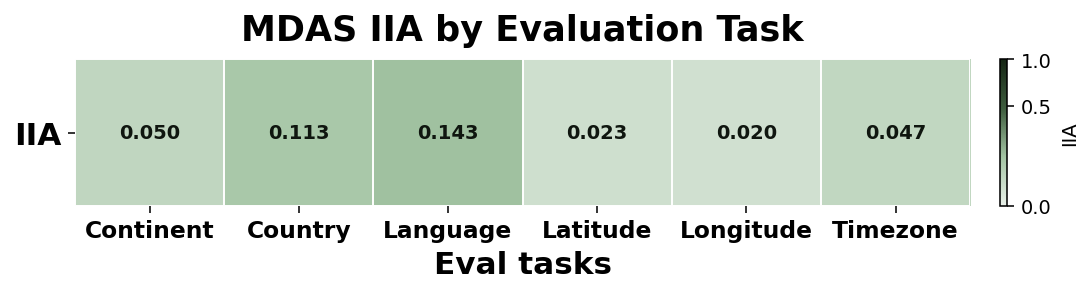

In [4]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, PowerNorm

ARTIFACTS = Path("../artifacts")
IIA_PATH = ARTIFACTS / "das_mdas_test_iia_by_attribute_diff_gold.json"

with open(IIA_PATH) as f:
    iia_data = json.load(f)

# Keep a fixed, readable eval-task order on x-axis.
tasks = ["Continent", "Country", "Language", "Latitude", "Longitude", "Timezone"]
values = np.array([float(iia_data[t]["iia"]) for t in tasks], dtype=float)[None, :]  # shape: (1, 6)

# Light -> dark green (stronger contrast than the old pastel ramp).
cmap = LinearSegmentedColormap.from_list(
    "iia_green",
    ["#E8F0E8", "#A3C4A3", "#3D5C3D", "#152614"],
)
norm = PowerNorm(gamma=0.55, vmin=0.0, vmax=1.0)

fig, ax = plt.subplots(figsize=(8, 2.2), dpi=140)
im = ax.imshow(values, cmap=cmap, norm=norm, aspect="auto")

ax.set_xticks(np.arange(len(tasks)))
ax.set_xticklabels(tasks, rotation=0, fontsize=12, fontweight="bold")
ax.set_yticks([0])
ax.set_yticklabels(["IIA"], fontsize=16, fontweight="bold")
ax.set_xlabel("Eval tasks", fontsize=16, fontweight="bold")
ax.set_title("MDAS IIA by Evaluation Task", fontsize=18, fontweight="bold", pad=10)

# Value labels: pick text color from cell luminance under the same norm/cmap.
for j, val in enumerate(values[0]):
    rgba = cmap(norm(val))
    luma = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
    text_color = "white" if luma < 0.48 else "#0F160F"
    ax.text(j, 0, f"{val:.3f}", ha="center", va="center", color=text_color, fontsize=10, fontweight="600")

cbar = fig.colorbar(im, ax=ax, fraction=0.07, pad=0.03)
cbar.set_label("IIA", rotation=90)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks(np.arange(-0.5, len(tasks), 1), minor=True)
ax.set_yticks(np.arange(-0.5, 1.5, 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.0)
ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()
plt.show()


## DAS IIA heatmaps (green colormap)

Replot of the layer × subspace grids saved as `das_heatmap_test.png` and `das_heatmap_test_global.png`, using the same green palette as the **MDAS IIA** section above. Values are loaded from `das_das_results.json` and `das_das_results_global.json` (same structure as `step2_das.plot_iia_heatmap`). If your PNGs came from another run, set `RESULTS_LOCAL` / `RESULTS_GLOBAL` to the matching `das_*_results.json`.

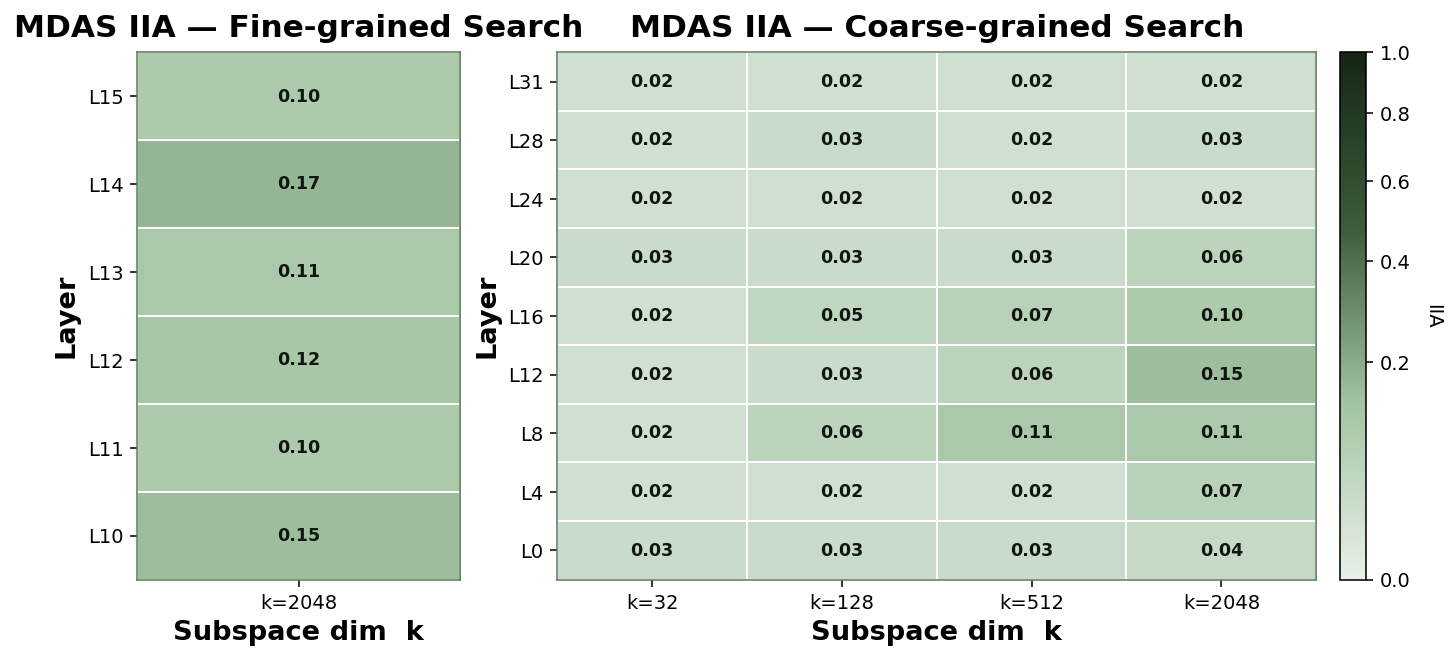

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, PowerNorm

cmap = LinearSegmentedColormap.from_list(
    "iia_green",
    ["#E8F0E8", "#A3C4A3", "#3D5C3D", "#152614"],
)
norm = PowerNorm(gamma=0.55, vmin=0.0, vmax=1.0)


def plot_das_heatmap(matrix, layers, k_dims, title, ax):
    im = ax.imshow(
        matrix,
        cmap=cmap,
        norm=norm,
        aspect="auto",
        origin="lower",
    )

    for i in range(len(layers)):
        for j in range(len(k_dims)):
            val = matrix[i, j]
            rgba = cmap(norm(val))
            luma = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            text_color = "white" if luma < 0.48 else "#0F160F"
            ax.text(
                j, i, f"{val:.2f}",
                ha="center", va="center",
                color=text_color, fontsize=9, fontweight="600",
            )

    ax.set_xticks(range(len(k_dims)))
    ax.set_xticklabels([f"k={k}" for k in k_dims])
    ax.set_yticks(range(len(layers)))
    ax.set_yticklabels([f"L{l}" for l in layers])

    ax.set_xlabel("Subspace dim  k", fontsize=14, fontweight="bold")
    ax.set_ylabel("Layer", fontsize=14, fontweight="bold")
    ax.set_title(title, fontsize=16, fontweight="bold", pad=8)

    ax.set_facecolor("#F0F5F0")
    for spine in ax.spines.values():
        spine.set_edgecolor("#5A7A5A")

    ax.set_xticks(np.arange(-0.5, len(k_dims), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(layers), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.0)
    ax.tick_params(which="minor", bottom=False, left=False)
    return im


# --- Data: local (entity token) vs global ---
layers_local = [10, 11, 12, 13, 14, 15]
k_local = [2048]
matrix_local = np.array([
    [0.15],
    [0.10],
    [0.12],
    [0.11],
    [0.17],
    [0.10],
])

layers_global = [0, 4, 8, 12, 16, 20, 24, 28, 31]
k_global = [32, 128, 512, 2048]
matrix_global = np.array([
    [0.03, 0.03, 0.03, 0.04],
    [0.02, 0.02, 0.02, 0.07],
    [0.02, 0.06, 0.11, 0.11],
    [0.02, 0.03, 0.06, 0.15],
    [0.02, 0.05, 0.07, 0.10],
    [0.03, 0.03, 0.03, 0.06],
    [0.02, 0.02, 0.02, 0.02],
    [0.02, 0.03, 0.02, 0.03],
    [0.02, 0.02, 0.02, 0.02],
])

fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4.6),
    dpi=140,
    layout="constrained",
    gridspec_kw={"width_ratios": [1, 2.35]},
)
im0 = plot_das_heatmap(
    matrix_local,
    layers_local,
    k_local,
    "MDAS IIA — Fine-grained Search",
    axes[0],
)
plot_das_heatmap(
    matrix_global,
    layers_global,
    k_global,
    "MDAS IIA — Coarse-grained Search",
    axes[1],
)
cbar = fig.colorbar(im0, ax=axes.ravel().tolist(), fraction=0.035, pad=0.02)
cbar.set_label("IIA", rotation=270, labelpad=16)
plt.show()
